# ACC 

10 consumidores - perfil consumo medio
* 5 200 kWh/mes => 2400 kWh/ano
* 5 300 kWh/mes => 3600 kWh/ano

Capacidade instalada 2.25 kWp => 2063€
* 1563€ sistema
* 350€ instalação
* 150€ sistema medição

Coeficientes de distribuição:
* Proporcionais ao consumo : fraccao entre consumo individual e total
* Fixos : cada consumidor com 10% da produção

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.optimize as optimize
import matplotlib.pyplot as plt
%matplotlib inline  
import locale
locale.setlocale(locale.LC_TIME, "pt_PT") # processar datas em PT
import aosol.series.consumo as series
import aosol.series.producao as seriesprod
import aosol.series.pvgis as pvgis
import aosol.analise.analise_energia as ae
import aosol.analise.analise_financeira as af
import aosol.analise.analise_precos_energia as ape
from aosol.armazenamento.bateria import bateria
from tabulate import tabulate

## Producao

In [15]:
# =====================
# Producao
# =====================
ano_producao = 2025 # converter as datas de producao para este ano
# Opcoes API PVGIS
inicio_ano_pvgis = 2005
fim_ano_pvgis = 2023 # PVGIS-SARAH3 na V5.3 (2005-2023)
inclinacao = 30
azimute = 0.0 # azimute = 180 + x; 0 = Sul
perdas = 14 # %
capacidade_instalada = 2.25 # kWp
eficiencia_inversor = 0.96
# Lisboa
lat = 38.736
lon = -9.143

In [3]:
producao_lisboa = pvgis.get_pvgis_hourly(lat, lon, inicio_ano_pvgis, fim_ano_pvgis, surface_tilt=inclinacao, surface_azimuth=azimute, peakpower=capacidade_instalada, loss=perdas)
producao_lisboa = seriesprod.converter_pvgis_multiyear_ts(producao_lisboa, ano_producao)

NEPS Lisboa = 1593 h


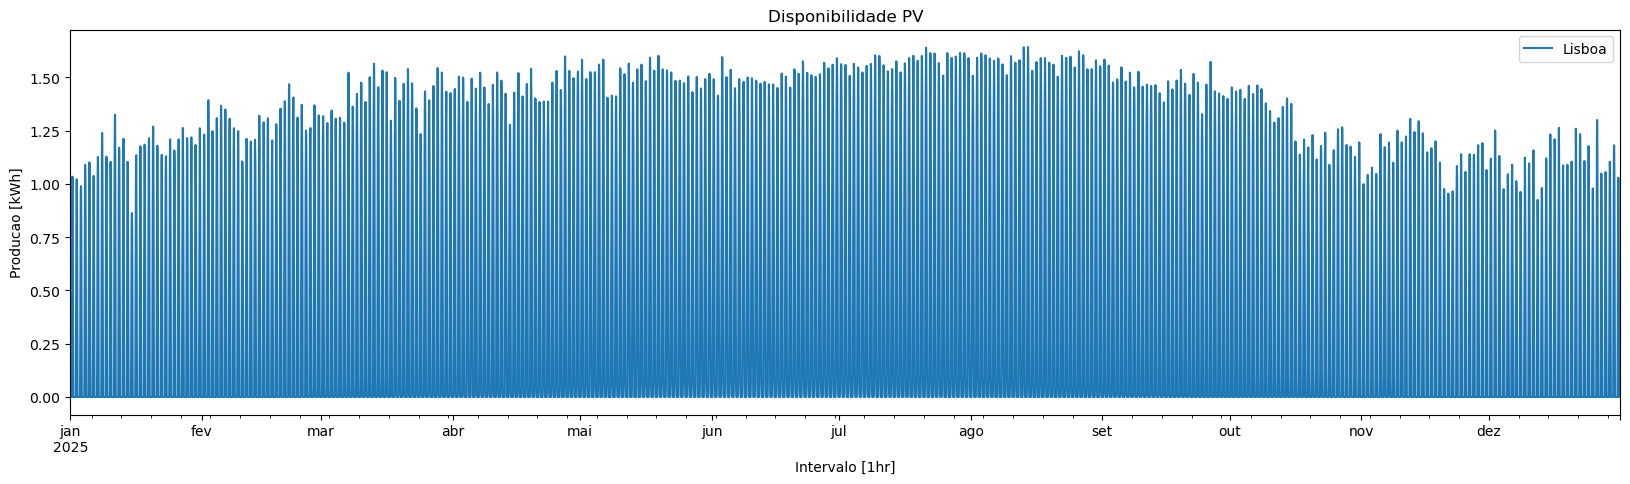

In [4]:
p,ax = plt.subplots(1,1, figsize=(20,5))
producao_lisboa["autoproducao"].plot(ax=ax, label='Lisboa')
plt.legend()
plt.ylabel('Producao [kWh]')
plt.xlabel('Intervalo [1hr]')
plt.title('Disponibilidade PV')

print(f"NEPS Lisboa = {producao_lisboa['autoproducao'].sum()/capacidade_instalada:.0f} h")

## Consumo

In [6]:
# =====================
# Consumo
# =====================
ano_consumo = 2025
perfil = 'BTN C' # ver na document
consumo_anual1 = 2400 # 200 kWh/mes
consumo_anual2 = 3600 # 300 kWh/mes
fich_perfil_eredes = r"./consumo/perfis_eredes/Perfil_Consumo_Injeção_E-REDES_2025.csv"

In [7]:
perfil_eredes = series.leitura_perfis_eredes(fich_perfil_eredes, perfil)
consumo_1 = series.ajustar_perfil_eredes_a_consumo_anual(perfil_eredes, consumo_anual1, 'BTN C', 'consumo')
consumo_2 = series.ajustar_perfil_eredes_a_consumo_anual(perfil_eredes, consumo_anual2, 'BTN C', 'consumo')

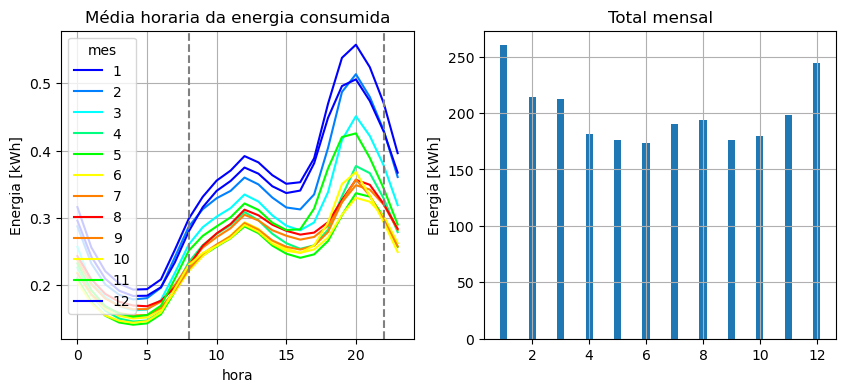

In [8]:
ae.plot_perfil_12x24_e_mensal(consumo_1, 'consumo')

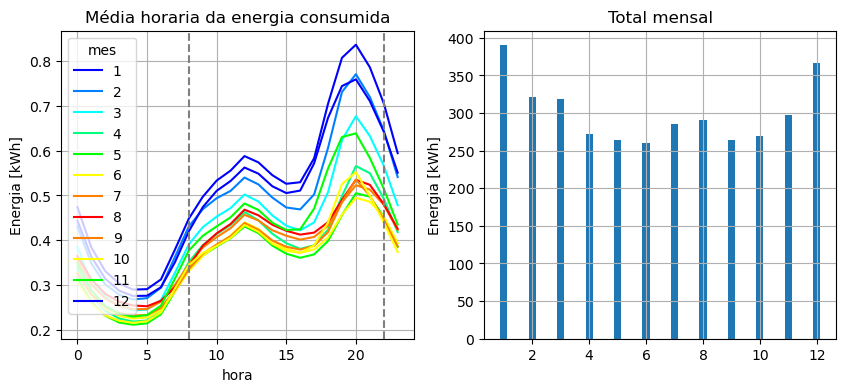

In [9]:
ae.plot_perfil_12x24_e_mensal(consumo_2, 'consumo')

### Coeficientes proporcionais ao consumo

In [11]:
# consumo total = 5 * consumo_1 + 5 * consumo_2
consumo_total_acc = consumo_1 * 5 + consumo_2 * 5
consumo_1['coeff_proporcional'] = consumo_1['consumo'] / consumo_total_acc['consumo']
consumo_2['coeff_proporcional'] = consumo_2['consumo'] / consumo_total_acc['consumo']


In [19]:
ano_tarifario = 2023
simples_kwh = 0.129 # simples
bihorario_fora_vazio_kwh = 0.0
bihorario_vazio_kwh = 0.0
trihorario_ponta_kwh = 0.0
trihorario_cheias_kwh = 0.0
trihorario_vazio_kwh = 0.0
# venda a rede com preco fixo
preco_venda_rede = 0.0 # 4cent/kWh
precos_energia = ape.TarifarioEnergia(simples_kwh, \
    bihorario_fora_vazio_kwh, bihorario_vazio_kwh, \
    trihorario_ponta_kwh, trihorario_cheias_kwh, trihorario_vazio_kwh, \
    preco_venda_rede)

#### Consumo 1 : 200 kWh/mes

In [16]:
# consumo_1 
energia_1 = consumo_1.copy()
energia_1["autoproducao"] = producao_lisboa["autoproducao"] * consumo_1['coeff_proporcional']

energia_1 = ae.analisa_upac_sem_armazenamento(energia_1)
indicadores_1 = ae.calcula_indicadores_autoconsumo(energia_1, capacidade_instalada, eficiencia_inversor)

In [18]:
indicadores_1.print_html("P50")

label,P50
Potencia instalada [kW],2.2
IAS: Contributo PV [%],11.9
IAC: Indice Auto consumo [%],100.0
IER: Producao PV desperdicada [%],0.0
Energia consumida [kWh],2399.8
Energia Autoproduzida [kWh],286.7
Energia Autoconsumida [kWh],286.7
Energia consumida rede [kWh],2113.1
Energia injectada rede [kWh],0.0
Perdas inversor [kWh],11.5


In [21]:
from IPython.display import display_html
mensal_simples = af.analise_poupanca_anual_fatura(energia_1, ape.Tarifario.Simples, precos_energia, False, ['consumo', 'consumo_rede'])
simples_styler = mensal_simples.style.format("{:.2f} €").set_caption('Tarifario Simples P50').set_table_attributes("style='display:inline'")
display_html(simples_styler._repr_html_(), raw=True)


,fatura sem upac,fatura com upac,poupanca
mes,,,
Janeiro,43.34 €,40.51 €,2.83 €
Fevereiro,36.17 €,33.06 €,3.11 €
Março,35.72 €,31.72 €,4.00 €
Abril,30.87 €,26.69 €,4.18 €
Maio,29.88 €,25.26 €,4.62 €
Junho,29.50 €,24.98 €,4.52 €
Julho,32.19 €,27.36 €,4.83 €
Agosto,32.78 €,28.03 €,4.75 €
Setembro,29.94 €,25.82 €,4.12 €


### Consumo 2 : 300 kWh/mes

In [31]:
# consumo_2
energia_2 = consumo_2.copy()
energia_2["autoproducao"] = producao_lisboa["autoproducao"] * consumo_2['coeff_proporcional']

energia_2 = ae.analisa_upac_sem_armazenamento(energia_2)
indicadores_2 = ae.calcula_indicadores_autoconsumo(energia_2, capacidade_instalada, eficiencia_inversor)

In [32]:
indicadores_2.print_html("P50")

label,P50
Potencia instalada [kW],2.2
IAS: Contributo PV [%],11.9
IAC: Indice Auto consumo [%],100.0
IER: Producao PV desperdicada [%],-0.0
Energia consumida [kWh],3599.7
Energia Autoproduzida [kWh],430.0
Energia Autoconsumida [kWh],430.0
Energia consumida rede [kWh],3169.7
Energia injectada rede [kWh],0.0
Perdas inversor [kWh],17.2


In [33]:

mensal_simples = af.analise_poupanca_anual_fatura(energia_2, ape.Tarifario.Simples, precos_energia, False, ['consumo', 'consumo_rede'])
simples_styler = mensal_simples.style.format("{:.2f} €").set_caption('Tarifario Simples P50').set_table_attributes("style='display:inline'")
display_html(simples_styler._repr_html_(), raw=True)

,fatura sem upac,fatura com upac,poupanca
mes,,,
Janeiro,64.13 €,59.88 €,4.25 €
Fevereiro,53.30 €,48.64 €,4.66 €
Março,52.69 €,46.70 €,5.99 €
Abril,45.40 €,39.13 €,6.27 €
Maio,43.93 €,36.99 €,6.94 €
Junho,43.34 €,36.57 €,6.77 €
Julho,47.40 €,40.15 €,7.25 €
Agosto,48.28 €,41.16 €,7.12 €
Setembro,44.00 €,37.82 €,6.18 €


### Coeficientes fixos

In [25]:
energia_1fixo = consumo_1.copy()
energia_1fixo["autoproducao"] = producao_lisboa["autoproducao"] * 0.1

energia_1fixo = ae.analisa_upac_sem_armazenamento(energia_1fixo)
indicadores_1fixo = ae.calcula_indicadores_autoconsumo(energia_1fixo, capacidade_instalada, eficiencia_inversor)

In [26]:
indicadores_1fixo.print_html("P50")

label,P50
Potencia instalada [kW],2.2
IAS: Contributo PV [%],14.9
IAC: Indice Auto consumo [%],100.0
IER: Producao PV desperdicada [%],0.0
Energia consumida [kWh],2399.8
Energia Autoproduzida [kWh],358.4
Energia Autoconsumida [kWh],358.4
Energia consumida rede [kWh],2041.5
Energia injectada rede [kWh],0.0
Perdas inversor [kWh],14.3


In [27]:

mensal_simples = af.analise_poupanca_anual_fatura(energia_1fixo, ape.Tarifario.Simples, precos_energia, False, ['consumo', 'consumo_rede'])
simples_styler = mensal_simples.style.format("{:.2f} €").set_caption('Tarifario Simples P50').set_table_attributes("style='display:inline'")
display_html(simples_styler._repr_html_(), raw=True)

,fatura sem upac,fatura com upac,poupanca
mes,,,
Janeiro,43.34 €,39.80 €,3.54 €
Fevereiro,36.17 €,32.29 €,3.88 €
Março,35.72 €,30.72 €,5.00 €
Abril,30.87 €,25.65 €,5.22 €
Maio,29.88 €,24.10 €,5.78 €
Junho,29.50 €,23.86 €,5.64 €
Julho,32.19 €,26.15 €,6.04 €
Agosto,32.78 €,26.85 €,5.93 €
Setembro,29.94 €,24.79 €,5.15 €


#### Consumo 2

In [28]:
energia_2fixo = consumo_2.copy()
energia_2fixo["autoproducao"] = producao_lisboa["autoproducao"] * 0.1

energia_2fixo = ae.analisa_upac_sem_armazenamento(energia_2fixo)
indicadores_2fixo = ae.calcula_indicadores_autoconsumo(energia_2fixo, capacidade_instalada, eficiencia_inversor)

In [29]:
indicadores_2fixo.print_html("P50")

label,P50
Potencia instalada [kW],2.2
IAS: Contributo PV [%],10.0
IAC: Indice Auto consumo [%],100.0
IER: Producao PV desperdicada [%],0.0
Energia consumida [kWh],3599.7
Energia Autoproduzida [kWh],358.4
Energia Autoconsumida [kWh],358.4
Energia consumida rede [kWh],3241.4
Energia injectada rede [kWh],0.0
Perdas inversor [kWh],14.3


In [30]:
mensal_simples = af.analise_poupanca_anual_fatura(energia_2fixo, ape.Tarifario.Simples, precos_energia, False, ['consumo', 'consumo_rede'])
simples_styler = mensal_simples.style.format("{:.2f} €").set_caption('Tarifario Simples P50').set_table_attributes("style='display:inline'")
display_html(simples_styler._repr_html_(), raw=True)

,fatura sem upac,fatura com upac,poupanca
mes,,,
Janeiro,64.13 €,60.58 €,3.55 €
Fevereiro,53.30 €,49.42 €,3.88 €
Março,52.69 €,47.69 €,5.00 €
Abril,45.40 €,40.17 €,5.23 €
Maio,43.93 €,38.15 €,5.78 €
Junho,43.34 €,37.70 €,5.64 €
Julho,47.40 €,41.36 €,6.04 €
Agosto,48.28 €,42.35 €,5.93 €
Setembro,44.00 €,38.85 €,5.15 €
